In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# DATA ACQUISITION (DAQ)

The goal is to validate the consistency of the loading process and obtain a preliminary overview of the available variables.

### Details of the operations performed:
* **Definition and loading (`pd.read_csv`):** The source folder (`../data/raw/`) is isolated to keep track of the raw, unmanipulated data, ensuring the reproducibility of the experiment.
* **Formal inspection (`df.shape`):** Returns the dimensionality of the data matrix to quantify the volume of information collected.
* **Consistency and data type analysis (`df.info()` and `df.dtypes`):** Allows mapping the type of each variable and detecting the presence of unhandled missing values.
* **Visual validation (`df.head()`):** Provides a preview of the first 5 rows to verify alignment and the correct parsing of column headers.

In [16]:
#dataset path definition
dataset_path = "../data/raw/capture20110815-2.csv"

In [17]:
print("--- Dataset loading... ---")

#load dataset
df = pd.read_csv(dataset_path)

print("--- Dataset loaded ---")

#number of rows and columns
print(f"Dimension of dataset: {df.shape}")

#dataset info
df.info()

print("--- Dataset types ---")
print(df.dtypes)

print("--- Verify correct load ---")
df.head()

--- Dataset loading... ---
--- Dataset loaded ---
Dimension of dataset: (129832, 15)
<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB
--- Dataset types ---
StartTime        str
Dur          flo

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


# DATA EXPLORATION (STATS & VISUALIZATION)

## Analysis of the Target Variable ('Label')
In this phase, the descriptive statistical analysis and graphical visualization of the dataset are performed. <br>
The main objective is to understand the nature of the problem (class balance) and study the behavior of the original numerical network traffic features to identify discriminating patterns.

In [18]:
print("\n--- Statistical exploration start ---")

#Analysis of the Target variable ('Label')
print("Distribution of original classes in the 'Label' column:")
print(df['Label'].value_counts(dropna=False))


--- Statistical exploration start ---
Distribution of original classes in the 'Label' column:
Label
flow=To-Background-UDP-CVUT-DNS-Server                      50817
flow=Background-UDP-Established                             37203
flow=Background-TCP-Established                             15156
flow=Background-Established-cmpgw-CVUT                       9331
flow=Background                                              3426
                                                            ...  
flow=From-Botnet-V46-TCP-HTTP-Google-Net-Established-6          1
flow=From-Botnet-V46-TCP-CC7-Custom-Encryption                  1
flow=From-Botnet-V46-TCP-Established-HTTP-Ad-4                  1
flow=From-Botnet-V46-TCP-Established-Custom-Encryption-8        1
flow=From-Botnet-V46-TCP-Established                            1
Name: count, Length: 77, dtype: int64


## Binary Mapping

**Binary mapping of the target (`Label` $\rightarrow$ `Target`):**<br>
The original `Label` column in the CTU-13 dataset contains detailed text strings describing the flows (e.g., *Botnet*, *Normal*, *Background*).<br>
In order to train a binary classifier, a string-matching process is performed using a lambda function: any record containing the substring `'Botnet'` is mapped to the positive class (`1`), while all remaining traffic is assimilated into the negative class (`0`).

In [19]:
# create target column: 1 if string contains 'Botnet', 0 otherwise (Normal and Background)
df['Target'] = df['Label'].apply(lambda x: 1 if 'Botnet' in str(x) else 0)
print("\nDistribution after binary mapping (Target):")
target_counts = df['Target'].value_counts()
print(target_counts)


Distribution after binary mapping (Target):
Target
0    128931
1       901
Name: count, dtype: int64


**Analysis and visualization of class imbalance (`Class Imbalance`):** <br>
Through the calculation of absolute and percentage frequencies, and representation via a bar chart (`sns.countplot`), the degree of dataset imbalance is quantified.<br>
In network traffic, Botnet traffic represents an extremely rare radar anomaly (often less than 1% of the total).


Class 0 (Normal/Background): 99.31%

Class 1(Botnet): 0.69%


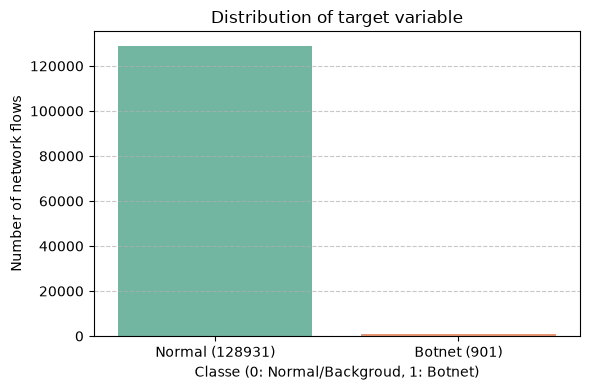

In [20]:
#percentage imbalance
p_normal = (target_counts[0] / len(df)) * 100
p_botnet = (target_counts[1] / len(df)) * 100
print(f"\nClass 0 (Normal/Background): {p_normal:.2f}%")
print(f"\nClass 1(Botnet): {p_botnet:.2f}%")

#graphic display of the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Target', hue='Target', data=df, palette='Set2', legend=False)
plt.title('Distribution of target variable')
plt.xlabel('Classe (0: Normal/Backgroud, 1: Botnet)')
plt.ylabel('Number of network flows')
plt.xticks([0,1], [f"Normal ({target_counts[0]})", f'Botnet ({target_counts[1]})'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Numerical Feature Exploration

**Statistical exploration of network features (`df.describe()`):**<br>
The main statistical metrics (mean, standard deviation, minimum, maximum, and percentiles) are extracted for the numerical variables that describe the flow dynamics: session duration (`Dur`), Type of Service (`dTos`), total packets exchanged (`TotPkts`), total bytes (`TotBytes`), and bytes sent from the source (`SrcBytes`).

**Distribution Analysis on a Logarithmic Scale (`sns.histplot`):**<br>
Network traffic metrics (particularly duration `Dur` and byte volumes) exhibit highly skewed distributions with extremely long tails (*heavy-tailed distributions*) due to bursts of volumetric attacks or persistent connections.<br>
To make the plot readable and understand how the key feature is distributed relative to the two classes, a logarithmic scale is applied to the x-axis (`log_scale=True`).


Descriptive statistics of numerical features:
                 Dur           dTos        TotPkts      TotBytes      SrcBytes
count  129832.000000  122936.000000  129832.000000  1.298320e+05  1.298320e+05
mean       77.439645       0.000724      34.514927  2.883615e+04  5.081775e+03
std       282.290550       0.043716    2494.261137  2.962769e+06  5.179676e+05
min         0.000000       0.000000       1.000000  6.000000e+01  0.000000e+00
25%         0.000304       0.000000       2.000000  2.140000e+02  7.600000e+01
50%         0.000739       0.000000       2.000000  2.660000e+02  8.100000e+01
75%         0.643476       0.000000       6.000000  7.410000e+02  4.600000e+02
max      1805.828491       3.000000  694553.000000  8.537041e+08  1.365468e+08


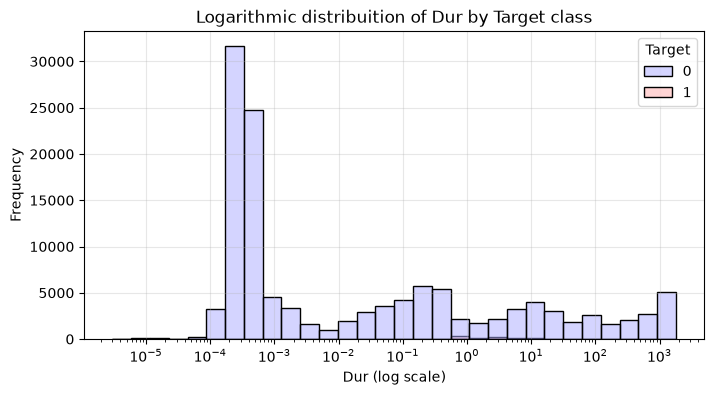

In [21]:
#numerical feature exploration
numerical_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes']

existing_numerical_features = [col for col in numerical_features if col in df.columns]

if existing_numerical_features:
    print("\nDescriptive statistics of numerical features:")
    print(df[existing_numerical_features].describe())

    #visualizing the distribution of a key feature
    plt.figure(figsize=(8,4))

    #logarithmic scale on the X-axis
    sns.histplot(data=df, x=existing_numerical_features[0], hue='Target', bins=30, kde=False, palette='bwr', log_scale=True)
    plt.title(f'Logarithmic distribuition of {existing_numerical_features[0]} by Target class')
    plt.xlabel(f'{existing_numerical_features[0]} (log scale)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\nNo numerical features found in the dataset for analysis.")

# Data Preprocessing

In this phase, the raw data is cleaned, transformed, and structured to maximize the informative power of the features and eliminate mathematical inconsistencies that would penalize the models.

In [22]:
print("\n --- Start Data Preprocessing ---")


 --- Start Data Preprocessing ---


**Port integration and sanitization (`clean_port`):**<br>
The network port columns (`Sport` / `Dport`) contain strings, hexadecimals, and null values (e.g., for ICMP packets).<br>
The `clean_port` function standardizes everything into integers, converting hexadecimals to base 16 and handling missing values using a fixed sentinel value (`-1`). This approach avoids One-Hot Encoding, which would cause the dataset dimensionality to explode (*Curse of Dimensionality*).

In [23]:
# operation of network ports
def clean_port(port_value):
    if pd.isna(port_value) or port_value == '':
        return -1
    if isinstance(port_value, str):
        port_value = port_value.strip().lower()
        if port_value.startswith('0x'):
            try:
                return int(port_value, 16)
            except ValueError:
                return -1
        try:
            return int(float(port_value))
        except ValueError:
            return -1
    try:
        return int(port_value)
    except:
        return -1

## TIME VARIABLE MANAGEMENT (StartTime)

**Cyclic time encoding:**<br>
Extracting the hour in a linear format (0-23) creates a false mathematical discontinuity (23:00 and 00:00 would appear 23 units apart rather than just one hour). By applying the trigonometric functions $\sin$ and $\cos$, time is mapped onto a circle, preserving temporal continuity.

In [24]:
#convert StartTime to datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])

#extracting hour of the day
df['HourOfDay'] = df['StartTime'].dt.hour
df['Hour_sin'] = np.sin(2 * np.pi * df['HourOfDay'] / 24.0)
df['Hour_cos'] = np.cos(2 * np.pi * df['HourOfDay'] / 24.0)
print("[Temporal Feature]: Applied cyclical Sine/Cosine encoding to 'HourOfDay'.")

[Temporal Feature]: Applied cyclical Sine/Cosine encoding to 'HourOfDay'.


## FEATURE SELECTION & TRANSFORMATION

**Feature selection & Variance thresholding:**<br>
Rigid identifiers (such as IP addresses) are removed to prevent *Data Leakage* (memorization of specific entities). Subsequently, the variance of each feature is calculated: columns with zero variance (lacking informational entropy) are removed to avoid noise and computational instability in linear models.

In [25]:
#select clean numeric features and exclude rigid identifiers (IP)
#include 'dTos' while handling its missing values

# imputation of missing values ​​for dTos
df['dTos'] = df['dTos'].fillna(0)

# port integration and cleaning
if 'Sport' in df.columns and 'Dport' in df.columns:
    print("[Network Feature]: Cleaning and integrating Source and Destination Ports...")
    df['Sport_Clean'] = df['Sport'].apply(clean_port)
    df['Dport_Clean'] = df['Dport'].apply(clean_port)
else:
    print("[Warning]: Sport or Dport columns not found. Fallback to default -1.")
    df['Sport_Clean'] = -1
    df['Dport_Clean'] = -1

# definition of Feature matrix (X) and Target vector (y)
selected_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Hour_sin', 'Hour_cos', 'Sport_Clean', 'Dport_Clean']
X = df[selected_features]
y = df['Target']

#remove any rows with 0 values in X or y
print("\n[Feature Selection]: Controllo delle feature con varianza zero...")

#compute variances for each column
variances = X.var(numeric_only=True)

#find columns with zero variance
zero_variance_cols = variances[variances == 0].index.tolist()

if zero_variance_cols:
    print(f"-> WARNING: You find features without any information content (variance=0): {zero_variance_cols}")
    print("-> Removing these columns to avoid noise and mathematical instability...")
    #remove zero variance columns from X
    X = X.drop(columns=zero_variance_cols)
else:
    print("-> No features with 0 variance found. All columns carry information.")

print(f"\n[Feature Selection]: Final features ready for the Train/Test Split: {X.columns.tolist()}")

[Network Feature]: Cleaning and integrating Source and Destination Ports...

[Feature Selection]: Controllo delle feature con varianza zero...
-> No features with 0 variance found. All columns carry information.

[Feature Selection]: Final features ready for the Train/Test Split: ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Hour_sin', 'Hour_cos', 'Sport_Clean', 'Dport_Clean']


## SPLIT TRAIN / TEST (Initial Hold-Out)

**Stratified Train/Test Split:**<br>
The dataset is split according to the Hold-Out method (70% Train, 30% Test). A stratification logic (`stratify=y`) is employed to ensure that the extremely low percentage of Botnet class samples is equally distributed between the two sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

print(f"[Train/Test Split]: Train Dimensions: {X_train.shape[0]}, Test Dimensions: {X_test.shape[0]}")

[Train/Test Split]: Train Dimensions: 90882, Test Dimensions: 38950


## NORMALIZATION (Feature Scaling)

**Independent Feature Scaling:**<br>
Using `StandardScaler`, the data is normalized to achieve a mean of 0 and a variance of 1. The scaler is fitted exclusively on the training set and applied as a transformation only on the test set, preventing any occurrence of *Information Leakage*.

In [27]:
scaler = StandardScaler()

#apply fit_transform on the Train and only transform on the Test (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("[Normalization]: Feature standardization completed (mean=0, variance=1).")

[Normalization]: Feature standardization completed (mean=0, variance=1).


## CLASS RE-BALANCING (Via SMOTE)

**Balancing via SMOTE:**<br>
Given the heavy asymmetry between the classes (botnet traffic accounting for less than 1%), the SMOTE technique is applied to generate synthetic vectors of the minority class through spatial interpolation of $k$-nearest neighbors. The algorithm acts only on the training set to train the models on balanced classes without contaminating the test set.

In [ ]:
#generate synthetic instances of the least represented class
print(f"Pre-SMOTE Class Distribution (Train): {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Post-SMOTE Class Distribution (Train): {np.bincount(y_train_resampled)}")
print("--- Data Preprocessing Completed ---")

Pre-SMOTE Class Distribution (Train): [90251   631]
Post-SMOTE Class Distribution (Train): [90251 90251]
--- Data Preprocessing Completed ---


# Data Processing & Modeling

In this section, three classifiers based on different principles are trained in order to evaluate which approach responds best to the inherent non-linearity of malicious network flows.

In [30]:
print("--- Start Data Processing & Modeling ---")

--- Start Data Processing & Modeling ---


## LOGISTIC REGRESSION
Represents the *Baseline Model*. It attempts to separate classes by drawing a linear hyperplane. Having treated network ports as continuous integers, this model will fail to effectively partition the space, as it interprets port numbers as quantitative magnitudes.

In [31]:
print("\n --- [Model 1] Logistic Regression Training ---")

# high max_iter to ensure gradient convergence
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_resampled, y_train_resampled)
print("-> Logistic regression trained.")


 --- [Model 1] Logistic Regression Training ---
-> Logistic regression trained.


## DECISION TREE
Builds a decision tree by performing sharp splits on the features (e.g., `if Dport_Clean <= 1024` or `if Dport_Clean == 6667`). It natively handles non-linear data and ports mapped as integers, but it is prone to overfitting on background noise.

In [32]:
print("\n[Model 2] Decision Tree Training ---")
model_dt = DecisionTreeClassifier(max_depth=None, min_samples_split=5, class_weight='balanced', random_state=42)
model_dt.fit(X_train_resampled, y_train_resampled)
print("-> Decision Tree trained.")


[Model 2] Decision Tree Training ---
-> Decision Tree trained.


## RANDOM FOREST
Builds an ensemble architecture of 200 independent decision trees trained on different subsets. The final classification is determined via majority vote (*hard voting*).<br>
This method drastically mitigates the variance and overfitting of a single tree, ensuring computational stability and high precision.

In [33]:
print("\n --- [Model 3] Random Forest Training ---")
#create a "forest" of 100 different decision trees that vote by majority vote
model_rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5,class_weight='balanced', random_state=42, n_jobs=-1)

model_rf.fit(X_train_resampled, y_train_resampled)
print("-> Random forest trained.")


 --- [Model 3] Random Forest Training ---
-> Random forest trained.


In [34]:
print("\n --- Completed: All models are ready for evaluation! ---")


 --- Completed: All models are ready for evaluation! ---


# Model Evaluation
In this section, a restrictive custom threshold of 0.85 is applied: a flow is classified as a Botnet only if the model expresses a confidence level equal to or greater than 85%.

### Validation tools used:
* **Classification report:** Allows analyzing metrics suited for imbalanced datasets: **Precision** (the ability to avoid generating false alarms) and **Recall** (the ability to intercept all real threats), synthesized by the **F1-Score**.
* **Confusion matrix display:** A graphical representation of True Positives, True Negatives, False Positives (harmless alarms), and False Negatives (missed attacks).
* **Unified ROC Curve and AUC:** A plot that maps the models' responsiveness across all possible mathematical thresholds. The AUC summarizes the model's discriminating power regardless of the chosen operational threshold, where a value close to 1.00 indicates an ideal classification.

--- Start Model Evaluation with Threshold Tuning ---

--- Evaluating Logistic Regression (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       1.00      0.96      0.98     38680
           Botnet       0.13      0.91      0.23       270

         accuracy                           0.96     38950
        macro avg       0.57      0.93      0.61     38950
     weighted avg       0.99      0.96      0.97     38950

Confusion Matrix (Testo):
 [[37081  1599]
 [   25   245]] 



<Figure size 500x400 with 0 Axes>

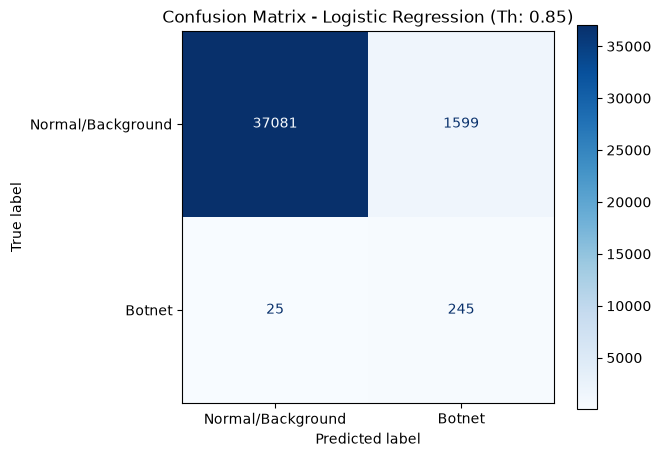

--- Completed evaluation of Logistic Regression ---


--- Evaluating Decision Tree (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       1.00      1.00      1.00     38680
           Botnet       0.90      0.96      0.93       270

         accuracy                           1.00     38950
        macro avg       0.95      0.98      0.96     38950
     weighted avg       1.00      1.00      1.00     38950

Confusion Matrix (Testo):
 [[38651    29]
 [   11   259]] 



<Figure size 500x400 with 0 Axes>

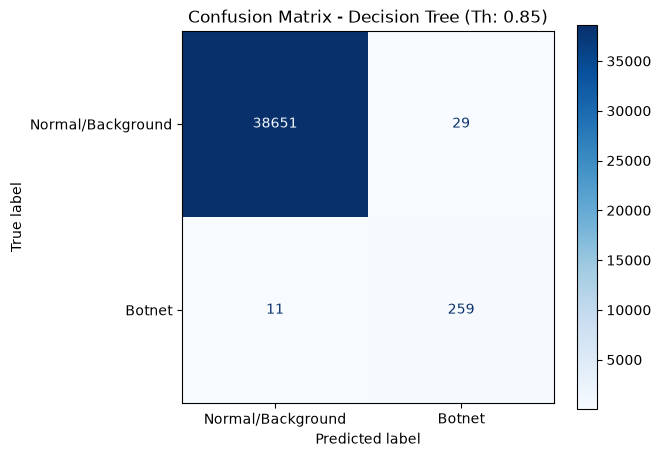

--- Completed evaluation of Decision Tree ---


--- Evaluating Random Forest (Threshold: 0.85) ---

[CLASSIFICATION REPORT - Threshold 0.85]
                   precision    recall  f1-score   support

Normal/Background       1.00      1.00      1.00     38680
           Botnet       0.99      0.91      0.95       270

         accuracy                           1.00     38950
        macro avg       0.99      0.95      0.97     38950
     weighted avg       1.00      1.00      1.00     38950

Confusion Matrix (Testo):
 [[38677     3]
 [   25   245]] 



<Figure size 500x400 with 0 Axes>

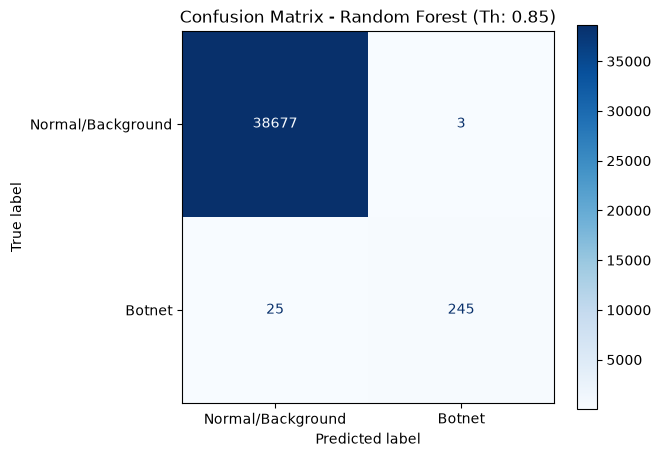

--- Completed evaluation of Random Forest ---


--- Generating Unified ROC Curve ---


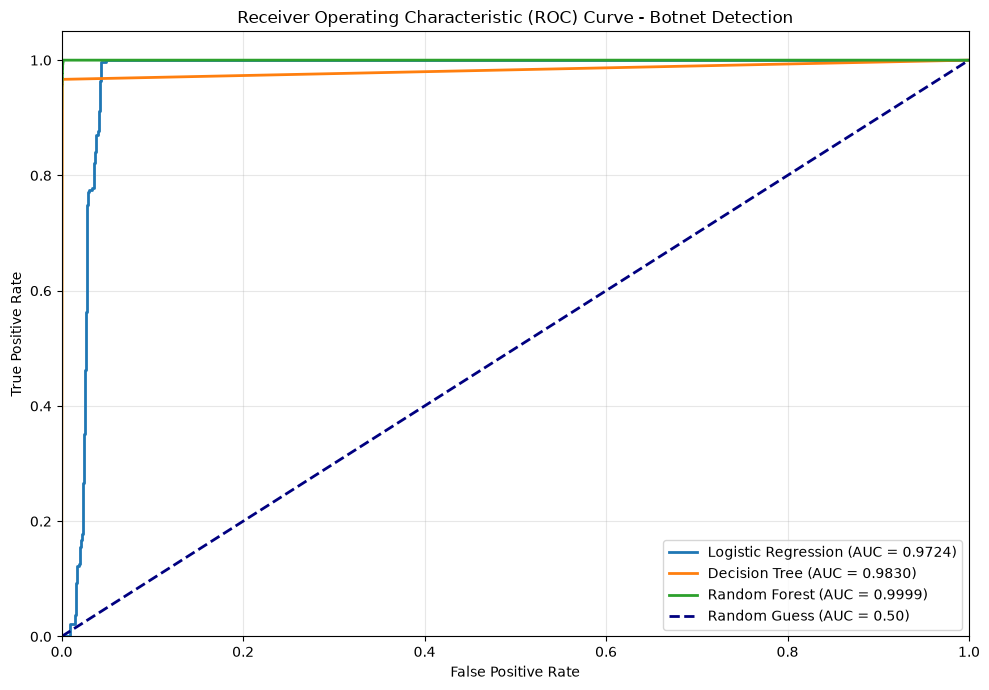

--- Completed: Evaluation successfully finished! ---


In [ ]:
print("--- Start Model Evaluation with Threshold Tuning ---")

#dictionary update with optimized trained versions
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

#threshold definition
custom_threshold = 0.85

#ROC data dictionary
roc_data_storage = {}

for name, model in models.items():
    print(f"\n========================================================")
    print(f"--- Evaluating {name} (Threshold: {custom_threshold}) ---")
    print(f"========================================================")

    #calculation of the probabilities of the Botnet class
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    #threshold application
    y_pred = (y_probs >= custom_threshold).astype(int)

    #printing text details
    print(f"\n[CLASSIFICATION REPORT - Threshold {custom_threshold}]")
    print(classification_report(y_test, y_pred, target_names=["Normal/Background", "Botnet"]))
    
    #textual calculation of the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix (Testo):\n", cm, "\n")

    #ROC points calculation and saving
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    roc_data_storage[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    #confusion matrix display
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        display_labels=["Normal/Background", "Botnet"], 
        cmap=plt.cm.Blues
    )
    plt.title(f"Confusion Matrix - {name} (Th: {custom_threshold})")
    plt.tight_layout()
    plt.show() 

    print(f"--- Completed evaluation of {name} ---\n")


#unified ROC CURVE
print("\n==========================================")
print("--- Generating Unified ROC Curve ---")
print("==========================================")


plt.figure(figsize=(10, 7))

#curves accumulated in the dictionary
for name, data in roc_data_storage.items():
    plt.plot(data["fpr"], data["tpr"], lw=2, label=f'{name} (AUC = {data["auc"]:.4f})')



plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Botnet Detection')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

#final unified ROC curve display
plt.show()

print("--- Completed: Evaluation successfully finished! ---")